# Analisis de Ventas E-commerce — Dashboard de KPIs

Este proyecto analiza un año de operacion (2025) de una tienda en linea ficticia
con datos de **pedidos**, **clientes** y **tráfico web**.

**Objetivos del analisis**
1. Calcular los KPIs clave del negocio (ingresos, AOV, conversion, retención).
2. Identificar tendencias, estacionalidad y categorías/canales top.
3. Segmentar clientes con un analisis RFM (Recencia, Frecuencia, Valor Monetario).
4. Construir un panel visual tipo *dashboard* que resuma todo lo anterior.

**Datos**
- `data/ecommerce_orders.csv` — 8,883 pedidos con producto, categoria, canal, region y cliente.
- `data/web_traffic.csv` — sesiones diarias del sitio web (para calcular conversión).


## 1. Carga y preparacion de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

orders = pd.read_csv("data/ecommerce_orders.csv", parse_dates=["order_date", "signup_date"])
traffic = pd.read_csv("data/web_traffic.csv", parse_dates=["date"])

print(f"Pedidos: {orders.shape[0]:,} filas | Rango: {orders['order_date'].min().date()} a {orders['order_date'].max().date()}")
print(f"Tráfico: {traffic.shape[0]:,} días")
orders.head()


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Chequeo rapido de calidad de datos
print("Nulos por columna:")
print(orders.isna().sum())
print("\nPedidos duplicados:", orders.duplicated(subset='order_id').sum())
print("Ingresos negativos o cero:", (orders['revenue'] <= 0).sum())


Nulos por columna:
order_id           0
order_date         0
customer_id        0
customer_region    0
signup_date        0
category           0
product            0
unit_price         0
quantity           0
discount_pct       0
revenue            0
channel            0
dtype: int64

Pedidos duplicados: 0
Ingresos negativos o cero: 0


## 2. KPIs principales

Calculamos los indicadores que normalmente se ven en un dashboard ejecutivo de e-commerce.

In [ ]:
total_revenue = orders["revenue"].sum()
total_orders = orders["order_id"].nunique()
aov = total_revenue / total_orders  # Average Order Value
total_customers = orders["customer_id"].nunique()

total_sessions = traffic["sessions"].sum()
overall_conversion = orders.shape[0] / total_sessions

# Clientes recurrentes (mas de 1 pedido en el año)
orders_per_customer = orders.groupby("customer_id")["order_id"].count()
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = repeat_customers / total_customers

kpi_summary = pd.DataFrame({
    "KPI": [
        "Ingresos totales", "Pedidos totales", "Valor promedio de pedido (AOV)",
        "Clientes únicos", "Tasa de conversión", "Tasa de recompra"
    ],
    "Valor": [
        f"${total_revenue:,.0f}", f"{total_orders:,}", f"${aov:,.2f}",
        f"{total_customers:,}", f"{overall_conversion:.2%}", f"{repeat_rate:.1%}"
    ]
})
kpi_summary


,KPI,Valor
0,Ingresos totales,"$489,750"
1,Pedidos totales,"8,883"
2,Valor promedio de pedido (AOV),$55.13
3,Clientes únicos,"2,882"
4,Tasa de conversión,4.36%
5,Tasa de recompra,76.6%


## 3. Tendencia de ingresos y estacionalidad

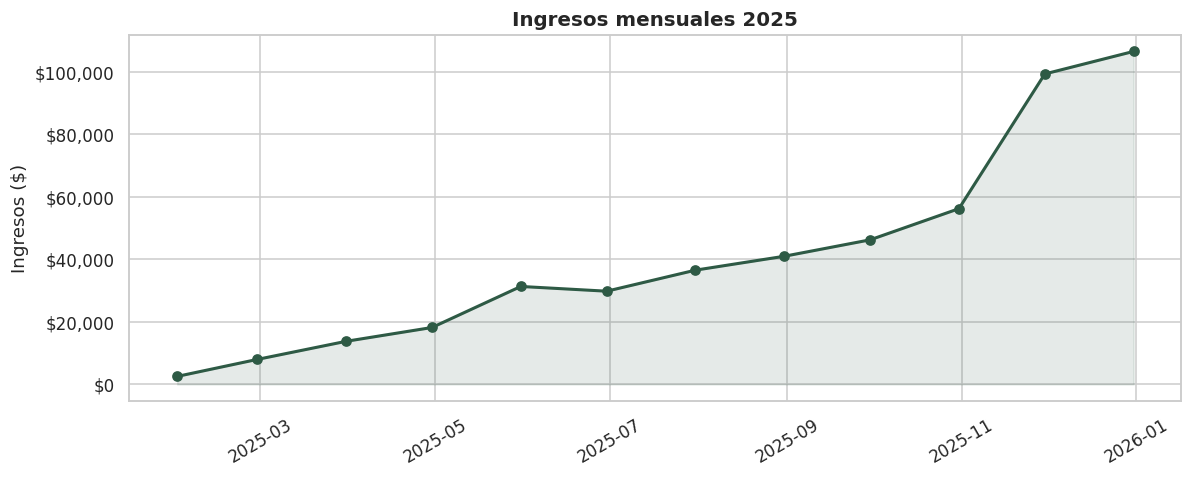

Mes con mayores ingresos: December 2025 ($106,580)


In [ ]:
monthly = orders.set_index("order_date").resample("ME")["revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#2E5A45")
ax.fill_between(monthly.index, monthly.values, color="#2E5A45", alpha=0.12)
ax.set_title("Ingresos mensuales 2025", fontsize=13, fontweight="bold")
ax.set_ylabel("Ingresos ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("")
for label in ax.get_xticklabels():
    label.set_rotation(30)
plt.tight_layout()
plt.show()

print("Mes con mayores ingresos:", monthly.idxmax().strftime("%B %Y"), f"(${monthly.max():,.0f})")


## 4. Desempeño por categoria y canal

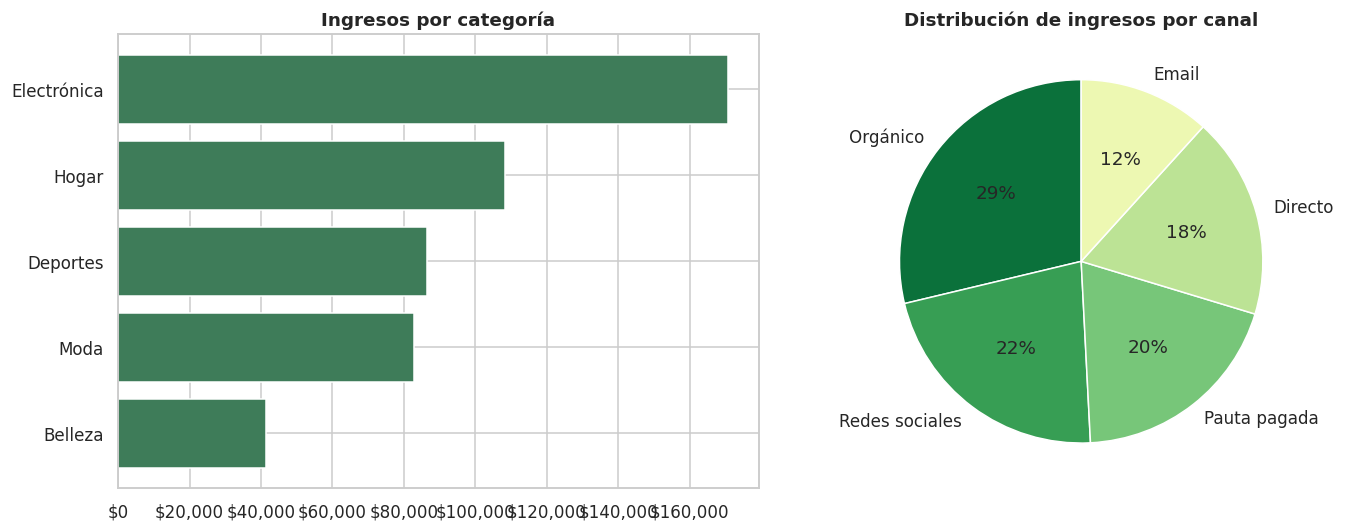

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_rev = orders.groupby("category")["revenue"].sum().sort_values(ascending=True)
axes[0].barh(cat_rev.index, cat_rev.values, color="#3E7C59")
axes[0].set_title("Ingresos por categoría", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

chan_rev = orders.groupby("channel")["revenue"].sum().sort_values(ascending=False)
axes[1].pie(chan_rev.values, labels=chan_rev.index, autopct="%1.0f%%",
            colors=sns.color_palette("YlGn", len(chan_rev))[::-1], startangle=90)
axes[1].set_title("Distribución de ingresos por canal", fontweight="bold")

plt.tight_layout()
plt.show()


In [ ]:
# Top 10 productos por ingresos
top_products = (orders.groupby(["product", "category"])["revenue"]
                 .sum().sort_values(ascending=False).head(10).reset_index())
top_products["revenue"] = top_products["revenue"].round(0)
top_products


,product,category,revenue
0,Smartwatch,Electrónica,48903.0
1,Power bank,Electrónica,42933.0
2,Audífonos BT,Electrónica,39680.0
3,Lámpara LED,Hogar,33895.0
4,Difusor aromas,Hogar,30578.0
5,Yoga mat,Deportes,27307.0
6,Mancuernas ajustables,Deportes,22871.0
7,Cargador rápido,Electrónica,22338.0
8,Camiseta básica,Moda,21632.0
9,Banda resistencia,Deportes,19736.0


## 5. Ventas por región

In [ ]:
region_summary = orders.groupby("customer_region").agg(
    ingresos=("revenue", "sum"),
    pedidos=("order_id", "count"),
    aov=("revenue", "mean"),
).round(2).sort_values("ingresos", ascending=False)
region_summary


,ingresos,pedidos,aov
customer_region,,,
Centro,139958.35,2482,56.39
Norte,111445.89,2013,55.36
Sur,91610.18,1680,54.53
Este,74464.54,1350,55.16
Oeste,72270.66,1358,53.22


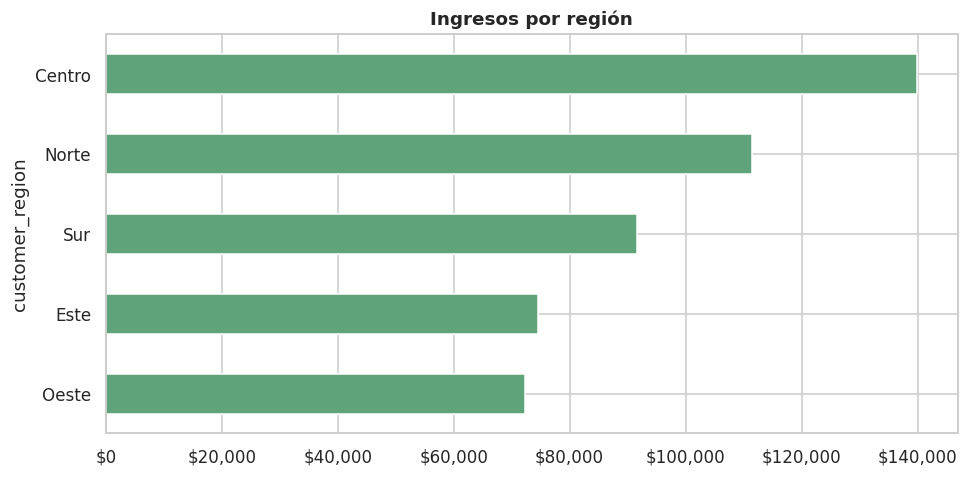

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
region_summary["ingresos"].sort_values().plot(kind="barh", ax=ax, color="#5FA37A")
ax.set_title("Ingresos por región", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


## 6. Tasa de conversion a lo largo del año

Relaciona sesiones del sitio web con pedidos concretados.

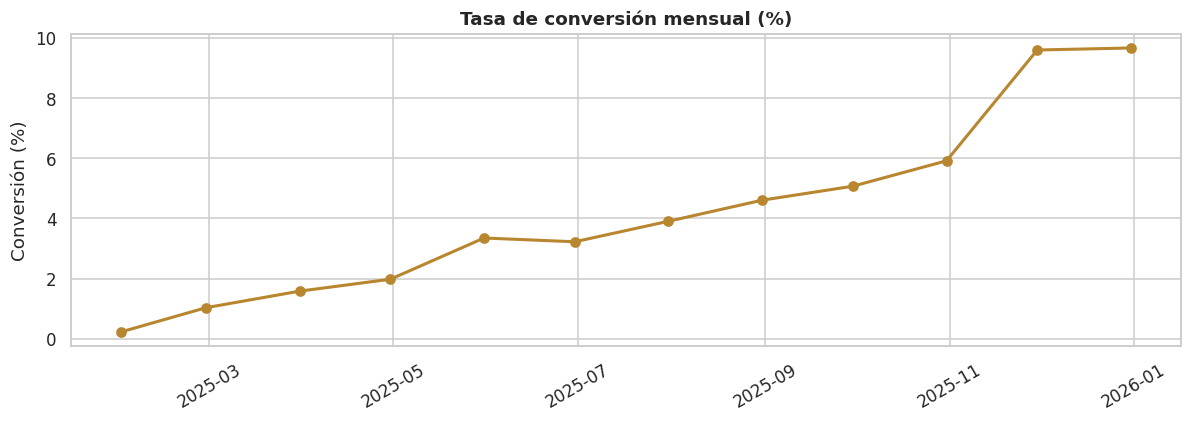

Conversión promedio anual: 4.18%


In [ ]:
traffic_monthly = traffic.set_index("date").resample("ME").agg(
    sessions=("sessions", "sum"), orders=("orders", "sum")
)
traffic_monthly["conversion_rate"] = traffic_monthly["orders"] / traffic_monthly["sessions"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(traffic_monthly.index, traffic_monthly["conversion_rate"] * 100,
        marker="o", color="#B8862F", linewidth=2)
ax.set_title("Tasa de conversión mensual (%)", fontweight="bold")
ax.set_ylabel("Conversión (%)")
for label in ax.get_xticklabels():
    label.set_rotation(30)
plt.tight_layout()
plt.show()

print(f"Conversion promedio anual: {traffic_monthly['conversion_rate'].mean():.2%}")


## 7. Segmentacion de clientes (analisis RFM)

- **Recencia**: dias desde la ultima compra.
- **Frecuencia**: numero de pedidos en el año.
- **Valor monetario**: gasto total del cliente.

Cada cliente recibe un puntaje de 1 (bajo) a 4 (alto) en cada dimension.

In [ ]:
snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("revenue", "sum"),
)

rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def segment(row):
    if row["RFM_score"] >= 10:
        return "Campeones"
    elif row["RFM_score"] >= 8:
        return "Leales"
    elif row["RFM_score"] >= 6:
        return "En riesgo"
    else:
        return "Inactivos / bajo valor"

rfm["segmento"] = rfm.apply(segment, axis=1)
seg_summary = rfm.groupby("segmento").agg(
    clientes=("recency", "count"), gasto_total=("monetary", "sum")
).sort_values("gasto_total", ascending=False)
seg_summary["% clientes"] = (seg_summary["clientes"] / seg_summary["clientes"].sum() * 100).round(1)
seg_summary


,clientes,gasto_total,% clientes
segmento,,,
Campeones,769,242543.70,26.7
Leales,670,127344.56,23.2
En riesgo,718,78556.70,24.9
Inactivos / bajo valor,725,41304.66,25.2


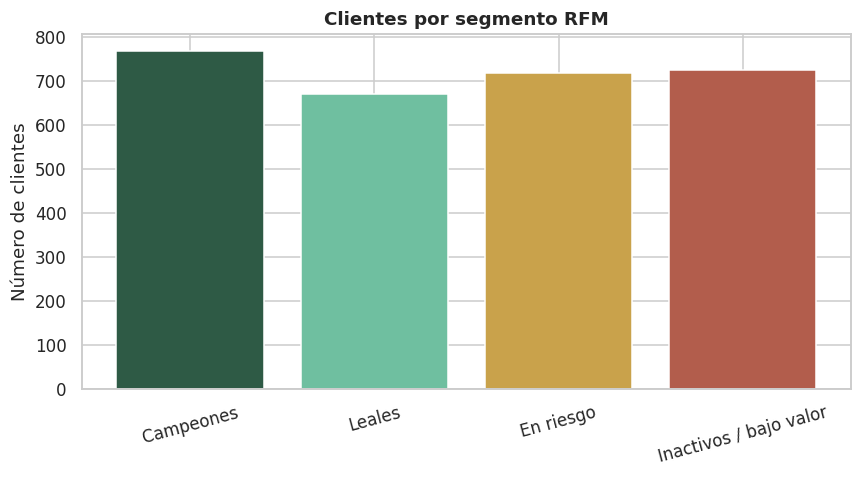

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2E5A45", "#6FBFA0", "#C9A24B", "#B25D4C"]
seg_order = ["Campeones", "Leales", "En riesgo", "Inactivos / bajo valor"]
vals = seg_summary.reindex(seg_order)["clientes"]
ax.bar(seg_order, vals, color=colors)
ax.set_title("Clientes por segmento RFM", fontweight="bold")
ax.set_ylabel("Numero de clientes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Dashboard resumen

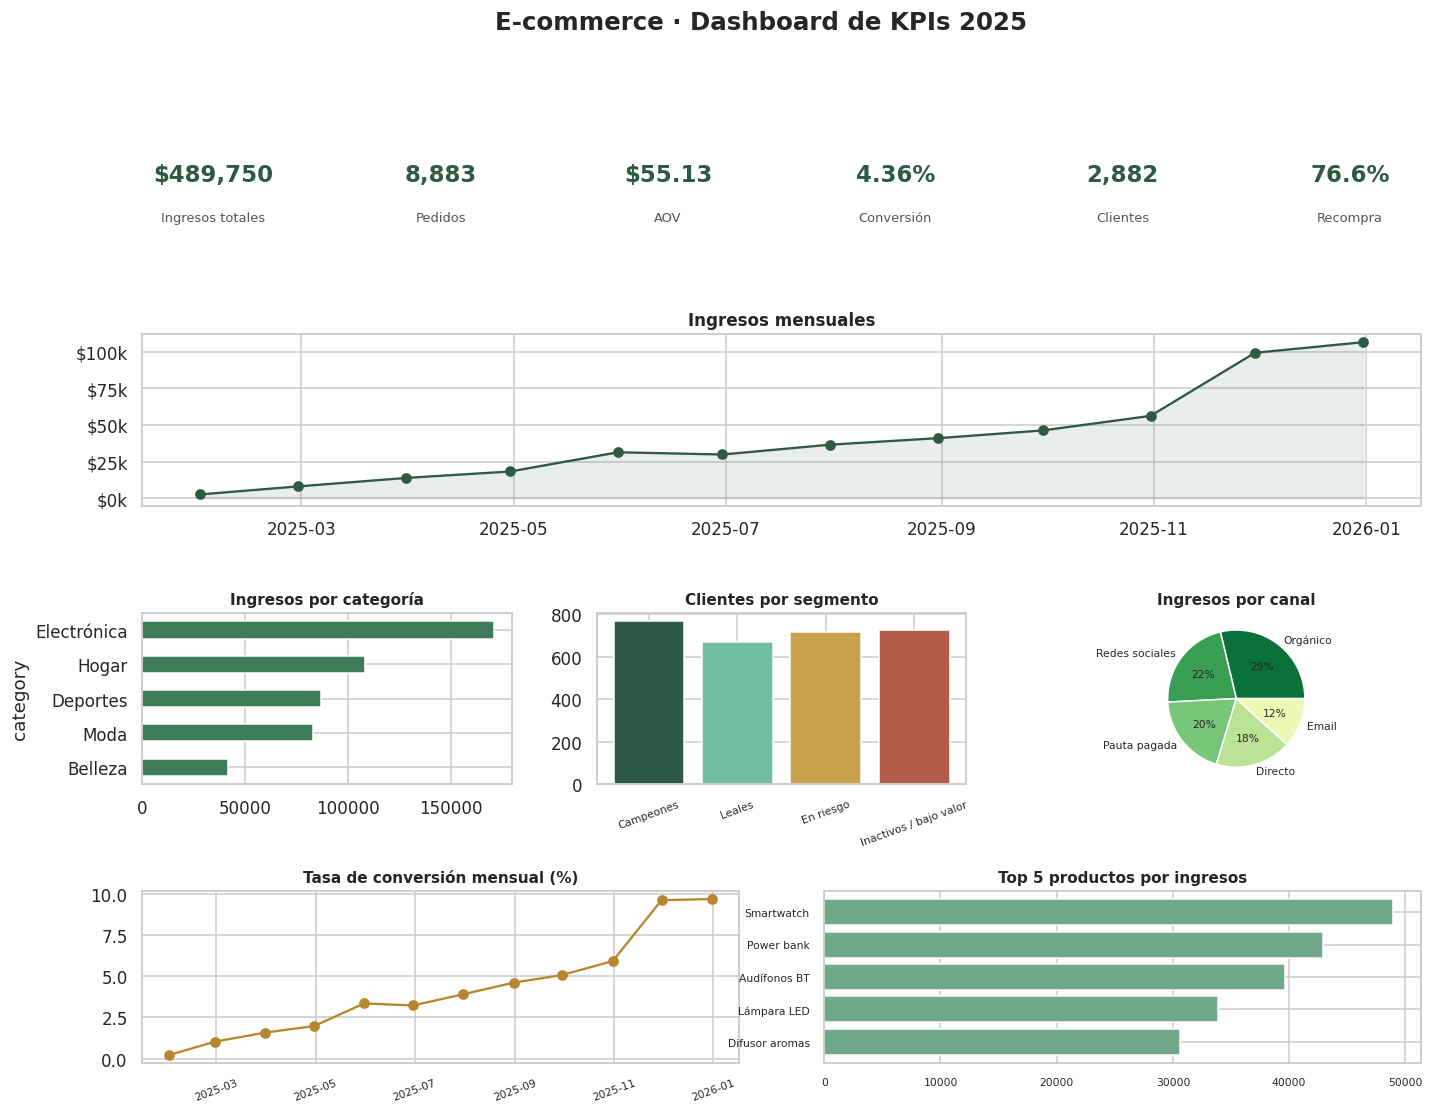

In [ ]:
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(4, 6, height_ratios=[0.9, 1.6, 1.6, 1.6], hspace=0.7, wspace=0.6)
fig.suptitle("E-commerce · Dashboard de KPIs 2025", fontsize=16, fontweight="bold", y=0.98)

# tarjetas KPI (una fila con las 6)
kpi_cards = [
    ("Ingresos totales", f"${total_revenue:,.0f}"),
    ("Pedidos", f"{total_orders:,}"),
    ("AOV", f"${aov:,.2f}"),
    ("Conversión", f"{overall_conversion:.2%}"),
    ("Clientes", f"{total_customers:,}"),
    ("Recompra", f"{repeat_rate:.1%}"),
]
for i, (label, value) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.text(0.5, 0.55, value, ha="center", va="center", fontsize=15, fontweight="bold", color="#2E5A45")
    ax.text(0.5, 0.1, label, ha="center", va="center", fontsize=8.5, color="#555")

# tendencia ingresos 
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(monthly.index, monthly.values, marker="o", color="#2E5A45")
ax4.fill_between(monthly.index, monthly.values, color="#2E5A45", alpha=0.1)
ax4.set_title("Ingresos mensuales", fontsize=11, fontweight="bold")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))

# categorías 
ax5 = fig.add_subplot(gs[2, 0:2])
cat_rev.plot(kind="barh", ax=ax5, color="#3E7C59")
ax5.set_title("Ingresos por categoría", fontsize=10, fontweight="bold")

# segmentos 
ax6 = fig.add_subplot(gs[2, 2:4])
ax6.bar(seg_order, vals, color=colors)
ax6.set_title("Clientes por segmento", fontsize=10, fontweight="bold")
ax6.tick_params(axis='x', labelrotation=20, labelsize=7)

# canal 
ax7 = fig.add_subplot(gs[2, 4:6])
ax7.pie(chan_rev.values, labels=chan_rev.index, autopct="%1.0f%%",
        colors=sns.color_palette("YlGn", len(chan_rev))[::-1], textprops={"fontsize": 7})
ax7.set_title("Ingresos por canal", fontsize=10, fontweight="bold")

# conversión mensual
ax8 = fig.add_subplot(gs[3, 0:3])
ax8.plot(traffic_monthly.index, traffic_monthly["conversion_rate"] * 100, marker="o", color="#B8862F")
ax8.set_title("Tasa de conversión mensual (%)", fontsize=10, fontweight="bold")
ax8.tick_params(axis='x', labelrotation=20, labelsize=7)

# top 5 productos
ax9 = fig.add_subplot(gs[3, 3:6])
top5 = top_products.head(5).sort_values("revenue")
ax9.barh(top5["product"], top5["revenue"], color="#6FA98A")
ax9.set_title("Top 5 productos por ingresos", fontsize=10, fontweight="bold")
ax9.tick_params(labelsize=7)

plt.savefig("dashboard_resumen.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Conclusion.

- **Estacionalidad clara**: noviembre y diciembre concentran los picos de ingresos (Black Friday / temporada navideña) — vale la pena reforzar inventario y campañas en esos meses.
- **Categorias top**: identificar qué categorías generan más ingresos ayuda a priorizar inversión en marketing y stock.
- **Conversion**: el sitio convierte sesiones en pedidos a una tasa estable; una prueba A/B en checkout podría mejorarla.
- **Segmentos RFM**: los "Campeones" y "Leales" son el motor de ingresos recurrentes — conviene diseñar programas de fidelización dirigidos a ellos, y campañas de reactivación para "En riesgo" e "Inactivos".

